In [1]:
import json
import math
import os
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Reset to matplotlib defaults
mpl.rcdefaults()

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
JSON_DIR = os.path.join(BASE_DIR, '..', 'json')
FIG_DIR  = BASE_DIR  # current ./ dir
os.makedirs(FIG_DIR, exist_ok=True)


# Only use powers of 2 for x-axis (equally spaced)
TARGET_KS = [1, 2, 4, 8, 16, 32, 64, 128]

# ── Font size config (change these to adjust all at once) ─────────────
FONT_LABEL    = 20   # x-axis, y-axis label
FONT_TICK     = 18   # tick numbers
FONT_LEGEND   = 18   # legend text
FONT_MARKER   = 6    # marker size
LINE_WIDTH    = 1.8  # line width
FIG_W, FIG_H  = 5.5, 3.5  # single figure size


def find_json(pattern):
    """Find a JSON file matching a glob pattern in JSON_DIR. Returns path or None."""
    matches = glob.glob(os.path.join(JSON_DIR, pattern))
    return matches[0] if matches else None

In [2]:
# ── Data loading ──────────────────────────────────────────────────────

def load_results(filepath):
    """Load JSON and return list of result dicts, sorted by top_k."""
    with open(filepath) as f:
        data = json.load(f)
    return sorted(data['results'], key=lambda r: r['top_k'])


def extract_series(results, model_key):
    """Extract (k_values, times, throughputs) for a specific model, filtered to TARGET_KS."""
    subset = [r for r in results if r['model'] == model_key and 'error' not in r]
    subset.sort(key=lambda r: r['top_k'])
    subset = [r for r in subset if r['top_k'] in TARGET_KS]
    ks    = [r['top_k'] for r in subset]
    times = [r['wall_time_sec'] for r in subset]
    thrs  = [math.ceil(r['total_throughput_rps'] * 100) / 100 for r in subset]
    return ks, times, thrs


# ── Evaluation Cluster ────────────────────────────────────────────────
eval_file = find_json('results_m=*_c=eval_cluster_k=*.json')

if eval_file:
    eval_results = load_results(eval_file)
    eval_llama_k, eval_llama_t, eval_llama_thr = extract_series(eval_results, 'llama3-70b')
    eval_qwen_k,  eval_qwen_t,  eval_qwen_thr  = extract_series(eval_results, 'qwen3-32b')
    print(f"Eval:  {os.path.basename(eval_file)}")
    print(f"  LLaMA k={eval_llama_k}, thr={eval_llama_thr}")
    print(f"  Qwen  k={eval_qwen_k},  thr={eval_qwen_thr}")
else:
    print('Eval cluster JSON not found — subplot (a) will be empty.')
    eval_llama_k = eval_llama_t = eval_llama_thr = []
    eval_qwen_k  = eval_qwen_t  = eval_qwen_thr  = []

# ── Large Cluster ────────────────────────────────────────────────────
large_file = find_json('results_m=*_c=large_hetero_cluster_k=*.json')

if large_file:
    large_results = load_results(large_file)
    large_llama_k, large_llama_t, large_llama_thr = extract_series(large_results, 'llama3-70b')
    large_qwen_k,  large_qwen_t,  large_qwen_thr  = extract_series(large_results, 'qwen3-32b')
    print(f"Large: {os.path.basename(large_file)}")
    print(f"  LLaMA k={large_llama_k}, thr={large_llama_thr}")
    print(f"  Qwen  k={large_qwen_k},  thr={large_qwen_thr}")
else:
    print('Large cluster JSON not found — subplot (b) will be empty.')
    large_llama_k = large_llama_t = large_llama_thr = []
    large_qwen_k  = large_qwen_t  = large_qwen_thr  = []

Eval:  results_m=llama3-70b+qwen3-32b_c=eval_cluster_k=1-128.json
  LLaMA k=[1, 2, 4, 8, 16, 32, 64, 128], thr=[2.39, 2.59, 2.84, 2.84, 2.84, 2.84, 2.84, 2.84]
  Qwen  k=[1, 2, 4, 8, 16, 32, 64, 128],  thr=[9.43, 9.43, 9.43, 9.43, 9.43, 9.43, 9.43, 9.43]
Large: results_m=llama3-70b+qwen3-32b_c=large_hetero_cluster_k=1-32.json
  LLaMA k=[1, 2, 4, 8, 16, 32], thr=[112.6, 112.58, 112.62, 112.65, 112.66, 112.66]
  Qwen  k=[1, 2, 4, 8, 16, 32],  thr=[212.36, 212.3, 212.3, 212.3, 212.3, 212.3]


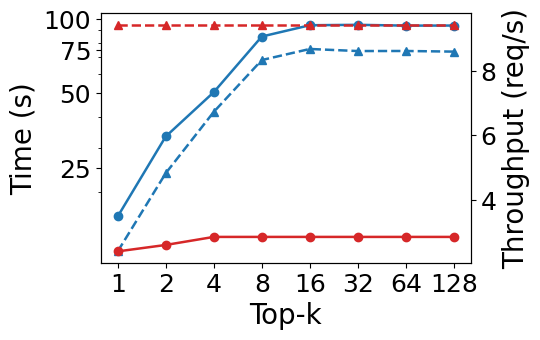

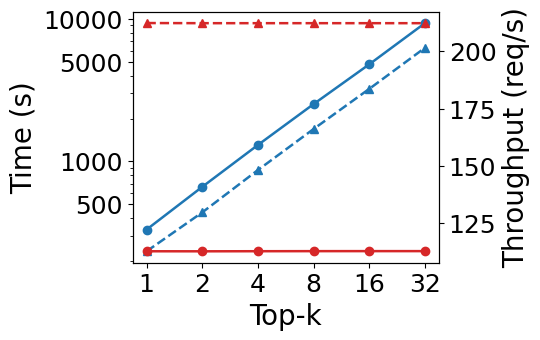

In [3]:
# ── Plotting ──────────────────────────────────────────────────────────
import matplotlib.ticker as ticker

MODEL_STYLES = {
    'llama3-70b': {'marker': 'o', 'ls_time': '-',  'ls_thr': '-',  'label': 'Llama3-70B'},
    'qwen3-32b':  {'marker': '^', 'ls_time': '--', 'ls_thr': '--', 'label': 'Qwen3-32B'},
}
COLOR_TIME = 'tab:blue'
COLOR_THR  = 'tab:red'


def plot_single(ax, llama_k, llama_t, llama_thr,
                qwen_k, qwen_t, qwen_thr, time_yticks=None):
    """Draw one cluster figure with dual y-axes. X-axis log2, Time y-axis log."""
    ax2 = ax.twinx()

    lines = []
    labels = []
    has_data = False

    for mk, ks, ts, thrs in [
        ('llama3-70b', llama_k, llama_t, llama_thr),
        ('qwen3-32b',  qwen_k,  qwen_t,  qwen_thr),
    ]:
        if not ks:
            continue
        has_data = True
        s = MODEL_STYLES[mk]

        l1, = ax.plot(ks, ts, color=COLOR_TIME, linestyle=s['ls_time'],
                      marker=s['marker'], markersize=FONT_MARKER, linewidth=LINE_WIDTH,
                      label=f"{s['label']} Time")
        l2, = ax2.plot(ks, thrs, color=COLOR_THR, linestyle=s['ls_thr'],
                       marker=s['marker'], markersize=FONT_MARKER, linewidth=LINE_WIDTH,
                       label=f"{s['label']} Throughput")
        lines.extend([l1, l2])
        labels.extend([l1.get_label(), l2.get_label()])

    ref_k = llama_k if llama_k else qwen_k
    ax.set_xscale('log', base=2)
    ax.set_xticks(ref_k)
    ax.set_xticklabels([str(k) for k in ref_k], fontsize=FONT_TICK)
    ax.minorticks_off()

    # Time y-axis: log scale with custom ticks
    ax.set_yscale('log')
    if time_yticks is not None:
        ax.set_yticks(time_yticks)
        ax.set_yticklabels([str(int(v)) for v in time_yticks])
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    ax.set_xlabel('Top-k', fontsize=FONT_LABEL)
    ax.set_ylabel('Time (s)', fontsize=FONT_LABEL)
    ax2.set_ylabel('Throughput (req/s)', fontsize=FONT_LABEL)
    ax.tick_params(axis='y', which='major', labelsize=FONT_TICK)
    ax2.tick_params(axis='y', labelsize=FONT_TICK)

    if not has_data:
        ax.text(0.5, 0.5, 'Data not yet available',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=FONT_LABEL, color='gray', fontstyle='italic')

    return lines, labels


# ── (a) Evaluation Cluster ────────────────────────────────────────────
fig_a, ax_a = plt.subplots(1, 1, figsize=(FIG_W, FIG_H))
lines_a, labels_a = plot_single(
    ax_a,
    eval_llama_k, eval_llama_t, eval_llama_thr,
    eval_qwen_k,  eval_qwen_t,  eval_qwen_thr,
    time_yticks=[25, 50, 75, 100],
)
fig_a.tight_layout()
fig_a.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_evaluation_cluster.pdf'), bbox_inches='tight', dpi=300)
fig_a.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_evaluation_cluster.png'), bbox_inches='tight', dpi=300)
plt.show()

# ── (b) Large Cluster ────────────────────────────────────────────────
fig_b, ax_b = plt.subplots(1, 1, figsize=(FIG_W, FIG_H))
lines_b, labels_b = plot_single(
    ax_b,
    large_llama_k, large_llama_t, large_llama_thr,
    large_qwen_k,  large_qwen_t,  large_qwen_thr,
    time_yticks=[500, 1000, 5000, 10000],
)
fig_b.tight_layout()
fig_b.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_large_cluster.pdf'), bbox_inches='tight', dpi=300)
fig_b.savefig(os.path.join(FIG_DIR, 'top_k_dp_result_large_cluster.png'), bbox_inches='tight', dpi=300)
plt.show()

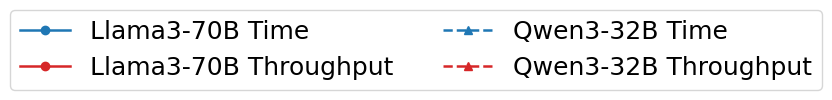

Saved: top_k_dp_result_evaluation_cluster, top_k_dp_result_large_cluster, top_k_legend


In [4]:
# ── Legend (separate file + display) ──────────────────────────────────
all_lines  = lines_a if lines_a else lines_b
all_labels = labels_a if labels_a else labels_b

fig_leg, ax_leg = plt.subplots(1, 1, figsize=(6, 0.8))
ax_leg.axis('off')
ax_leg.legend(all_lines, all_labels, loc='center', ncol=2, frameon=True, fontsize=FONT_LEGEND)
fig_leg.savefig(os.path.join(FIG_DIR, 'top_k_legend.pdf'), bbox_inches='tight', dpi=300)
fig_leg.savefig(os.path.join(FIG_DIR, 'top_k_legend.png'), bbox_inches='tight', dpi=300)
plt.show()

print(f'Saved: top_k_dp_result_evaluation_cluster, top_k_dp_result_large_cluster, top_k_legend')